# Classificação de Imagens no CIFAR-100 com ResNet Customizada
> **Desenvolvedor:** Luiggi  
> **Objetivo:** Treinar uma arquitetura residual customizada para reconhecer 100 classes de objetos, utilizando técnicas avançadas de regularização e otimização com Adam. Além de tentar conseguir 85% de acurácia na validação.

## 1. Configuração do Ambiente e Bibliotecas
Iniciamos a configuração do ambiente de desenvolvimento, realizando a importação das bibliotecas essenciais para manipulação de dados, visualização e Deep Learning (TensorFlow/Keras). Além disso, validamos a disponibilidade da GPU para garantir a aceleração do hardware durante o treinamento.

In [ ]:
import os
import pickle
import glob
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Configuração de log do TensorFlow (Suprime mensagens informativas/warnings)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def carregar_cifar100_local():
    """
    Localiza e carrega o dataset CIFAR-100 no ambiente Kaggle, 
    suportando tanto o formato comprimido (.tar.gz) quanto arquivos descompactados.
    """
    print("Iniciando busca pelo dataset CIFAR-100 no ambiente Kaggle...")
    
    # Tentativa A: Dataset em formato compactado (.tar.gz)
    tar_files = glob.glob('/kaggle/input/**/cifar-100-python.tar.gz', recursive=True)
    if tar_files:
        print("Arquivo .tar.gz detectado. Transferindo para o cache do Keras...")
        os.makedirs('/root/.keras/datasets', exist_ok=True)
        shutil.copy(tar_files[0], '/root/.keras/datasets/cifar-100-python.tar.gz')
        from tensorflow.keras.datasets import cifar100
        return cifar100.load_data()
        
    # Tentativa B: Dataset descompactado (arquivos 'train' e 'test')
    train_files = glob.glob('/kaggle/input/**/train', recursive=True)
    test_files = glob.glob('/kaggle/input/**/test', recursive=True)
    
    if train_files and test_files:
        print("Arquivos brutos detectados. Carregando dados via processamento local...")
        def unpickle(file):
            with open(file, 'rb') as fo:
                return pickle.load(fo, encoding='bytes')
                
        train_dict = unpickle(train_files[0])
        test_dict = unpickle(test_files[0])
        
        # Ajuste de dimensões para o formato (N, H, W, C) requerido pelo Keras
        x_train = train_dict[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        y_train = np.array(train_dict[b'fine_labels']).reshape(-1, 1)
        
        x_test = test_dict[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        y_test = np.array(test_dict[b'fine_labels']).reshape(-1, 1)
        
        print("Dataset carregado com sucesso.")
        return (x_train, y_train), (x_test, y_test)
        
    raise FileNotFoundError("Dataset CIFAR-100 não localizado. Verifique se o input foi adicionado.")

# Definições globais de otimização
AUTOTUNE = tf.data.AUTOTUNE

print(f"Versão TensorFlow: {tf.__version__}")
print(f"GPUs detectadas: {tf.config.list_physical_devices('GPU')}")

## 2. Definição da Arquitetura (ResNet Customizada)
Nesta etapa, estruturamos a arquitetura da rede neural baseada no conceito de conexões residuais (skip connections), o que permite o treinamento de redes profundas evitando a degradação de gradiente. Implementamos também um pipeline de Data Augmentation diretamente na GPU para aumentar a robustez do modelo frente ao overfitting.

In [ ]:
def criar_resnet_definitiva_cifar100():
    """
    Constrói e retorna a arquitetura ResNet customizada.
    Inclui camadas de Data Augmentation, blocos residuais e regularização L2
    para prevenir overfitting no dataset CIFAR-100.
    """
    inputs = layers.Input(shape=(32, 32, 3))
    
    # --- Pipeline de Data Augmentation ---
    # Aumenta a variabilidade dos dados de treino, tornando o modelo mais robusto
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomTranslation(0.1, 0.1, fill_mode="reflect")(x)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # --- Convolução Inicial ---
    # Extração de características base
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # --- Definição do Bloco Residual ---
    def res_block(x, filters, stride=1):
        """
        Cria um bloco residual com conexão de atalho (shortcut).
        Utiliza BatchNormalization e Dropout para estabilizar o treino.
        """
        shortcut = x
        
        # Primeira convolução do bloco
        x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.2)(x) # Regularização para reduzir overfitting
        
        # Segunda convolução do bloco
        x = layers.Conv2D(filters, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        
        # Ajuste de dimensões do shortcut (necessário se o stride > 1 ou filtros mudarem)
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
            
        x = layers.add([x, shortcut]) # Conexão residual (Soma)
        x = layers.Activation('relu')(x)
        return x

    # --- Empilhamento da Arquitetura ---
    x = res_block(x, 128, stride=1)
    x = res_block(x, 128, stride=1) 
    x = res_block(x, 256, stride=2) # Redução de dimensionalidade (downsampling)
    x = res_block(x, 512, stride=2)
    x = res_block(x, 1024, stride=2)
    
    # --- Classificador Final ---
    x = layers.GlobalAveragePooling2D()(x) # Converte mapas de características em vetor 1D
    x = layers.Dropout(0.4)(x)             # Regularização final densa
    outputs = layers.Dense(100, activation='softmax')(x)
    
    return models.Model(inputs, outputs, name="ResNet_Ultimate")

# Exemplo de uso:
model = criar_resnet_definitiva_cifar100()
print("Arquitetura criada com sucesso!")

## 3. Carregamento e Pré-processamento do Dataset
Realizamos a leitura do dataset CIFAR-100 a partir dos arquivos locais, aplicando a normalização de pixels para a escala [0, 1]. Adicionalmente, preparamos os dados para o treinamento utilizando o pipeline tf.data, convertendo as labels para o formato one-hot encoding, essencial para técnicas de suavização de rótulos (Label Smoothing)

In [ ]:
# --- Carregamento dos dados ---
(x_train, y_train), (x_test, y_test) = carregar_cifar100_local()

# --- Normalização e Pré-processamento ---
# Escalonamento dos pixels para o intervalo [0, 1] para auxiliar na convergência do gradiente
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Conversão das labels para formato One-Hot Encoding
# Necessário para compatibilidade com a função de perda 'CategoricalCrossentropy'
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=100)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=100)

# --- Criação do Pipeline tf.data ---
# Utilização de prefetch e buffer para otimizar o fluxo de dados entre CPU e GPU
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_one_hot))
train_ds = train_ds.shuffle(5000).batch(128).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_one_hot))
val_ds = val_ds.batch(128).prefetch(AUTOTUNE)

# --- Log de verificação ---
print(f"Formato dos dados de treino: {x_train.shape}")
print(f"Formato dos dados de teste:  {x_test.shape}")

## 4. Compilação, Treinamento do Modelo e Geração de Gráficos
Configuramos o ciclo de treinamento utilizando o otimizador Adam com decaimento de peso (Weight Decay) e Cosine Decay para a taxa de aprendizado. Para garantir um treino estável e eficiente, integramos callbacks estratégicos como ModelCheckpoint (salvando o melhor modelo), EarlyStopping (prevenção de overfitting) e CSVLogger para registro do histórico de métricas.

In [ ]:
from tensorflow.keras.callbacks import CSVLogger

# --- Configuração de Treinamento ---
RODADA_ENSEMBLE = 3  
NOME_ARQUIVO = f'/kaggle/working/modelo_v{RODADA_ENSEMBLE}.keras'
TOTAL_EPOCAS = 100
passos_por_epoca = len(train_ds)

# 1. Inicialização da arquitetura
model = criar_resnet_definitiva_cifar100()

# 2. Configuração do Scheduler (Cosine Decay)
# Reduz a taxa de aprendizado gradualmente para refinamento dos pesos no final do treino
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=TOTAL_EPOCAS * passos_por_epoca,
    alpha=0.01 
)

# 3. Otimizador AdamW (Adam com Weight Decay)
# O Weight Decay ajuda a manter os pesos menores, reduzindo a complexidade do modelo
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

# 4. Função de perda com Label Smoothing
# Reduz a confiança excessiva do modelo em previsões corretas, melhorando a generalização
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# 5. Compilação
model.compile(
    optimizer=optimizer, 
    loss=loss_fn, 
    metrics=['accuracy']
)

# 6. Callbacks: Monitoramento e Segurança
# CSVLogger: Registra histórico para análise posterior
# ModelCheckpoint: Salva apenas o melhor modelo (evita perda de progresso)
# EarlyStopping: Interrompe treino se não houver melhora (paciência de 10 épocas)
csv_logger = CSVLogger(f'/kaggle/working/historico_rodada_{RODADA_ENSEMBLE}.csv', append=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=10, 
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        NOME_ARQUIVO, 
        save_best_only=True, 
        monitor='val_accuracy'
    ),
    csv_logger
]

# 7. Execução do Treino
print(f"--- INICIANDO TREINAMENTO: MODELO {RODADA_ENSEMBLE} ---")
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=TOTAL_EPOCAS, 
    callbacks=callbacks
)
print(f"--- MODELO {RODADA_ENSEMBLE} FINALIZADO E SALVO ---")

In [ ]:
# --- Visualização de Performance: Acurácia e Loss ---
# Carrega os dados (certifique-se de que o CSV existe na pasta /kaggle/working/)
df = pd.read_csv(f'/kaggle/working/historico_rodada_{RODADA_ENSEMBLE}.csv')

# Cria figura com dois subplots (lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Acurácia ---
ax1.plot(df['epoch'], df['accuracy'], label='Treino', marker='.', linestyle='-')
ax1.plot(df['epoch'], df['val_accuracy'], label='Validação', marker='.', linestyle='-')
ax1.set_title(f'Acurácia - Rodada {RODADA_ENSEMBLE}')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- Gráfico 2: Loss (Perda) ---
ax2.plot(df['epoch'], df['loss'], label='Treino', marker='.', linestyle='-')
ax2.plot(df['epoch'], df['val_loss'], label='Validação', marker='.', linestyle='-')
ax2.set_title(f'Loss (Perda) - Rodada {RODADA_ENSEMBLE}')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Finalização e salvamento
plt.tight_layout()
plt.savefig(f'/kaggle/working/performance_rodada_{RODADA_ENSEMBLE}.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Avaliação Final: Ensemble e Métricas
Após a execução das rodadas de treinamento, realizamos a inferência consolidada através da técnica de Ensemble (média das predições de múltiplos modelos). A avaliação do desempenho é detalhada através do relatório de classificação e da matriz de confusão, fornecendo uma visão clara da capacidade de generalização do modelo final nas 20 superclasses do CIFAR-100.

In [ ]:
# --- Estratégia de Ensemble (Model Averaging) ---
# Carregamos os modelos individualmente, extraímos as predições e limpamos a memória.
# Essa abordagem reduz a variância das predições, resultando em maior acurácia final.

modelos_caminhos = sorted(glob.glob('/kaggle/working/modelo_v*.keras'))

if not modelos_caminhos:
    print("ERRO: Nenhum modelo encontrado. Treine pelo menos uma rodada!")
else:
    print(f"Iniciando Ensemble com {len(modelos_caminhos)} modelos...")
    
    lista_predicoes = []
    
    for caminho in modelos_caminhos:
        print(f"Processando: {os.path.basename(caminho)}...")
        
        # Carrega o modelo
        model_temp = load_model(caminho)
        
        # Realiza a predição no conjunto de teste
        pred = model_temp.predict(x_test, verbose=0)
        lista_predicoes.append(pred)
        
        # Limpeza rigorosa da memória GPU/RAM (essencial no Kaggle)
        tf.keras.backend.clear_session()
        del model_temp
        gc.collect()

    # Cálculo da média aritmética das probabilidades
    # Isso combina a "opinião" de cada modelo para a decisão final
    pred_ensemble = np.mean(lista_predicoes, axis=0)
    
    # Seleção da classe com maior probabilidade média
    y_pred_final = np.argmax(pred_ensemble, axis=1)
    
    print("--- ENSEMBLE CONCLUÍDO COM SUCESSO! ---")

--- INICIANDO AVALIAÇÃO DO ENSEMBLE (3 MODELOS) ---
Processando: modelo_v1.keras...
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step
Processando: modelo_v2.keras...
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step
Processando: modelo_v3.keras...
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step

--- CLASSIFICATION REPORT (100 CLASSES) ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.85      0.94      0.89       100
           2       0.69      0.61      0.65       100
           3       0.76      0.55      0.64       100
           4       0.50      0.58      0.54       100
           5       0.76      0.74      0.75       100
           6       0.78      0.85      0.81       100
           7       0.82      0.75      0.79       100
           8       0.81      0.89      0.85       100
           9       0.88      0.78      0.83       100
          10       0.46      0.72      0.56       100
          11       0.56      0.5

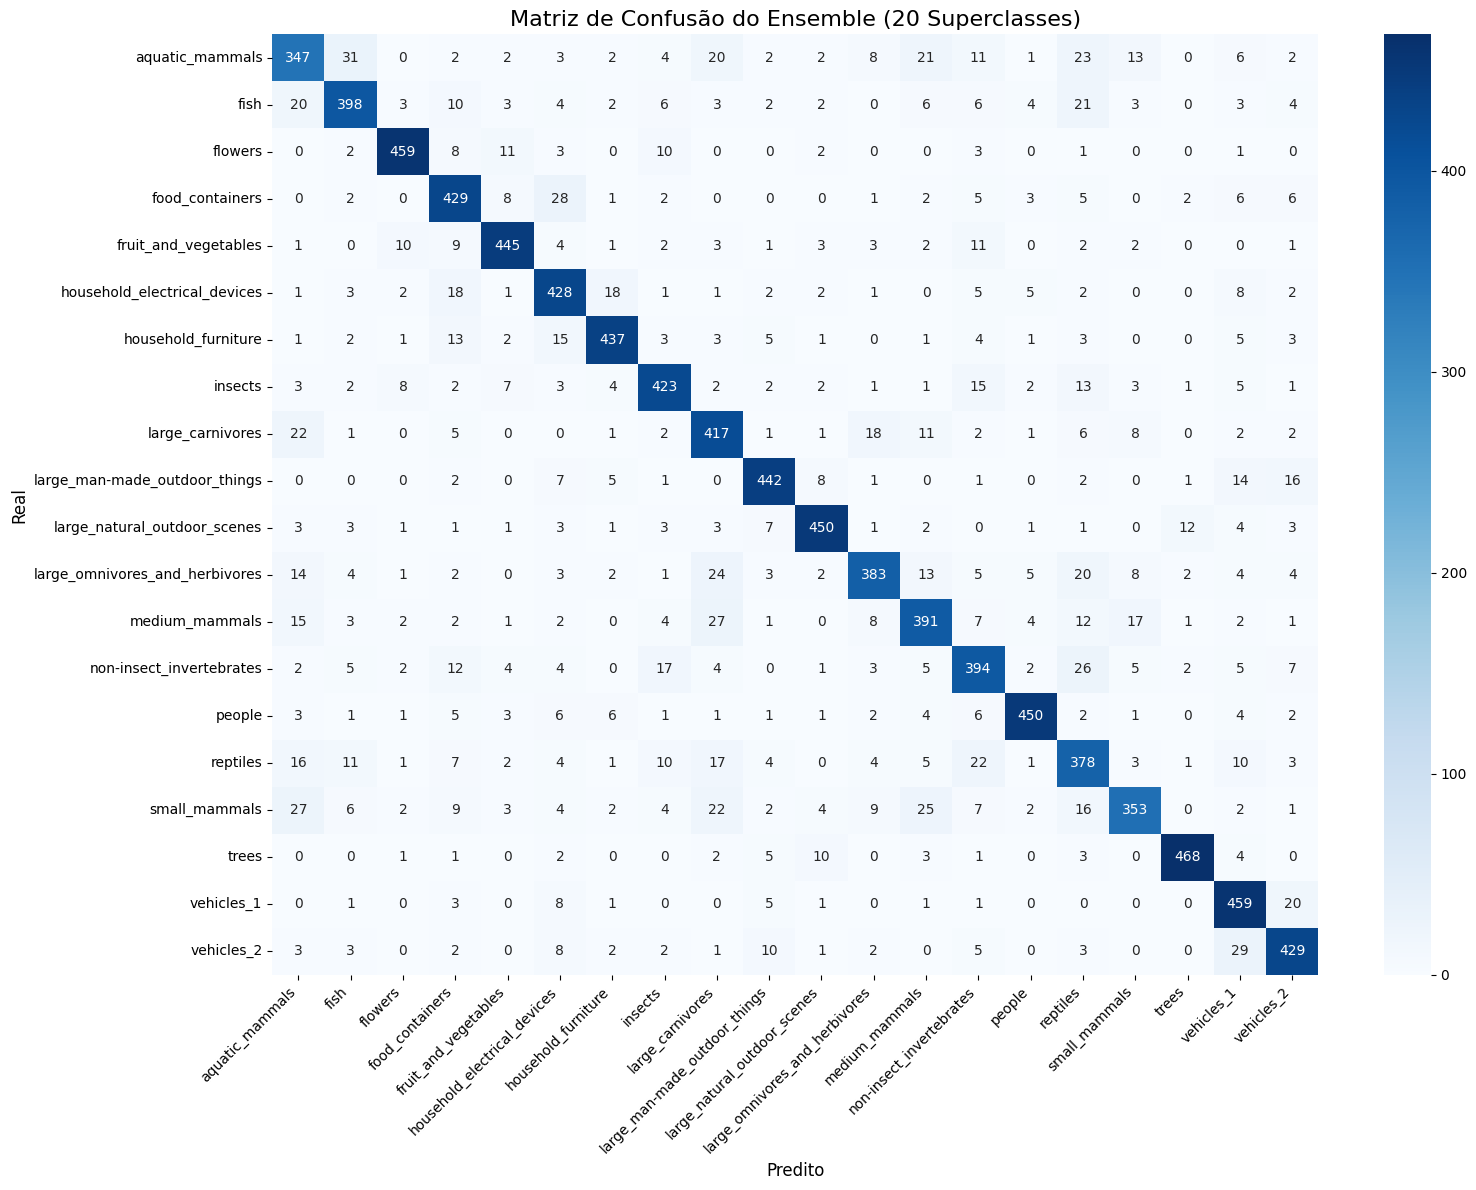

In [3]:
# --- AVALIAÇÃO DO ENSEMBLE E MATRIZ DE CONFUSÃO ---

print("--- INICIANDO AVALIAÇÃO DO ENSEMBLE (3 MODELOS) ---")

# 1. Carregar os caminhos dos arquivos necessários (caso ainda não estejam em cache)
test_files = glob.glob('/kaggle/input/**/test', recursive=True)
train_files = glob.glob('/kaggle/input/**/train', recursive=True)
meta_files = glob.glob('/kaggle/input/**/meta', recursive=True)

# 2. Carregar dados de teste
with open(test_files[0], 'rb') as fo:
    test_dict = pickle.load(fo, encoding='bytes')

x_test = test_dict[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1) / 255.0
y_test_fine = np.array(test_dict[b'fine_labels'])
y_test_coarse = np.array(test_dict[b'coarse_labels'])

# 3. Ensemble (Média das probabilidades)
modelos_caminhos = sorted(glob.glob('/kaggle/working/modelo_v*.keras'))
lista_predicoes = []

for caminho in modelos_caminhos:
    print(f"Processando: {os.path.basename(caminho)}...")
    model_temp = load_model(caminho)
    lista_predicoes.append(model_temp.predict(x_test, batch_size=64))
    
    # Limpeza de memória
    tf.keras.backend.clear_session()
    del model_temp
    gc.collect()

pred_ensemble_prob = np.mean(lista_predicoes, axis=0)
preds_fine = np.argmax(pred_ensemble_prob, axis=1)

# 4. Relatório (100 Classes - Fine)
print("\n--- CLASSIFICATION REPORT (100 CLASSES) ---")
print(classification_report(y_test_fine, preds_fine))

# 5. Mapeamento para Coarse (Superclasses)
fine_to_coarse = {}
for f in train_files: 
    with open(f, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
        for f_l, c_l in zip(d[b'fine_labels'], d[b'coarse_labels']):
            fine_to_coarse[f_l] = c_l

preds_coarse = np.array([fine_to_coarse[p] for p in preds_fine])

# Carregar nomes das superclasses
if meta_files:
    with open(meta_files[0], 'rb') as fo:
        meta_dict = pickle.load(fo, encoding='bytes')
    nomes = [name.decode('utf-8') for name in meta_dict[b'coarse_label_names']]
else:
    nomes = [str(i) for i in range(20)]

# 6. Plot Matriz de Confusão
cm = confusion_matrix(y_test_coarse, preds_coarse)

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=nomes, 
    yticklabels=nomes
)

plt.title('Matriz de Confusão do Ensemble (20 Superclasses)', fontsize=16)
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predito', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Resumo da Arquitetura (Model Summary)
Apresentamos o resumo estrutural do modelo final. Esta visualização detalha a contagem de camadas e a distribuição de parâmetros, confirmando a complexidade da rede e a organização dos blocos residuais construídos.

In [ ]:
from tensorflow.keras.models import load_model

# 1. Carrega o modelo (se já estiver na memória, ele apenas sobrescreve a referência)
model = load_model('/kaggle/working/modelo_v3.keras')

# 2. Imprime o contador de camadas com destaque
print("="*40)
print(f"RESUMO DA ARQUITETURA: {len(model.layers)} CAMADAS")
print("="*40)

# 3. Imprime o resumo detalhado
model.summary()